In [4]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers
import Gain
import MIWAE
import time
import SoftImpute
import TabCSDI


In [5]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from SoftImpute import softimpute, cv_softimpute
from TabCSDI import TabCSDIImputer


In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [7]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

Loading the data

In [8]:
data = fetch_openml(data_id=151,as_frame=True)
X_full = data.data.copy()

In [9]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45312 entries, 0 to 45311
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   date       45312 non-null  float64 
 1   day        45312 non-null  category
 2   period     45312 non-null  float64 
 3   nswprice   45312 non-null  float64 
 4   nswdemand  45312 non-null  float64 
 5   vicprice   45312 non-null  float64 
 6   vicdemand  45312 non-null  float64 
 7   transfer   45312 non-null  float64 
dtypes: category(1), float64(7)
memory usage: 2.5 MB
None


converting day coloumn to float

In [10]:
X_full['day'] = X_full['day'].astype(float)

In [11]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45312 entries, 0 to 45311
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       45312 non-null  float64
 1   day        45312 non-null  float64
 2   period     45312 non-null  float64
 3   nswprice   45312 non-null  float64
 4   nswdemand  45312 non-null  float64
 5   vicprice   45312 non-null  float64
 6   vicdemand  45312 non-null  float64
 7   transfer   45312 non-null  float64
dtypes: float64(8)
memory usage: 2.8 MB
None


In [12]:
print(X_full)

         date  day    period  nswprice  nswdemand  vicprice  vicdemand  \
0      0.0000  2.0  0.000000  0.056443   0.439155  0.003467   0.422915   
1      0.0000  2.0  0.021277  0.051699   0.415055  0.003467   0.422915   
2      0.0000  2.0  0.042553  0.051489   0.385004  0.003467   0.422915   
3      0.0000  2.0  0.063830  0.045485   0.314639  0.003467   0.422915   
4      0.0000  2.0  0.085106  0.042482   0.251116  0.003467   0.422915   
...       ...  ...       ...       ...        ...       ...        ...   
45307  0.9158  7.0  0.914894  0.044224   0.340672  0.003033   0.255049   
45308  0.9158  7.0  0.936170  0.044884   0.355549  0.003072   0.241326   
45309  0.9158  7.0  0.957447  0.043593   0.340970  0.002983   0.247799   
45310  0.9158  7.0  0.978723  0.066651   0.329366  0.004630   0.345417   
45311  0.9158  7.0  1.000000  0.050679   0.288753  0.003542   0.355256   

       transfer  
0      0.414912  
1      0.414912  
2      0.414912  
3      0.414912  
4      0.414912  
...

MinMax Scaling

In [13]:
#scaler = MinMaxScaler() #data [0,1]
#X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

scaler = StandardScaler()
X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [14]:
GroundTruth = X_full.copy()
X = X_full.copy()

In [15]:
print(GroundTruth)

           date       day    period  nswprice  nswdemand  vicprice  \
0     -1.466570 -1.002254 -1.696335 -0.035641   0.084111 -0.000003   
1     -1.466570 -1.002254 -1.624149 -0.154270  -0.063451 -0.000003   
2     -1.466570 -1.002254 -1.551967 -0.159521  -0.247451 -0.000003   
3     -1.466570 -1.002254 -1.479781 -0.309658  -0.678290 -0.000003   
4     -1.466570 -1.002254 -1.407598 -0.384751  -1.067236 -0.000003   
...         ...       ...       ...       ...        ...       ...   
45307  1.224554  1.499406  1.407598 -0.341190  -0.518892 -0.042498   
45308  1.224554  1.499406  1.479781 -0.324686  -0.427801 -0.038680   
45309  1.224554  1.499406  1.551967 -0.356969  -0.517067 -0.047394   
45310  1.224554  1.499406  1.624149  0.219620  -0.588118  0.113872   
45311  1.224554  1.499406  1.696335 -0.179776  -0.836787  0.007340   

          vicdemand  transfer  
0     -6.259668e-07 -0.558215  
1     -6.259668e-07 -0.558215  
2     -6.259668e-07 -0.558215  
3     -6.259668e-07 -0.558215  

In [16]:
GroundTruth.nunique()

date          933
day             7
period         48
nswprice     4089
nswdemand    5266
vicprice     3798
vicdemand    2846
transfer     1878
dtype: int64

Converting GroundTruth to tensor

In [17]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)

In [18]:
print("date",GroundTruth['date'].unique())
print("day",GroundTruth['day'].unique())
print("period",GroundTruth['period'].unique())
print("nswprice",GroundTruth['nswprice'].unique())
print("nswdemand",GroundTruth["nswdemand"].unique())
print("vicprice",GroundTruth['vicprice'].unique())
print("vicdemand",GroundTruth['vicdemand'].unique())
print("transfer",GroundTruth['transfer'].unique())

date [-1.46656991 -1.46644061 -1.46631132 -1.46617908 -1.46604979 -1.46592049
 -1.46579119 -1.46565896 -1.46552966 -1.46540037 -1.46527107 -1.46513884
 -1.46500954 -1.46488024 -1.46475095 -1.46461871 -1.46448942 -1.46436012
 -1.46423082 -1.46409859 -1.46396929 -1.46384    -1.4637107  -1.46357847
 -1.46344917 -1.45434848 -1.45421919 -1.45408695 -1.45395765 -1.45382836
 -1.45369906 -1.45356683 -1.45343753 -1.45330824 -1.45317894 -1.4530467
 -1.45291741 -1.45278811 -1.45265882 -1.45252658 -1.45239729 -1.45226799
 -1.45213869 -1.45200646 -1.45187716 -1.45174787 -1.45161857 -1.45148633
 -1.45135704 -1.45122774 -1.45109845 -1.45096915 -1.45083692 -1.45070762
 -1.45057832 -1.4413454  -1.4412161  -1.44108681 -1.44095751 -1.44082528
 -1.44069598 -1.44056669 -1.44043739 -1.44030515 -1.44017586 -1.44004656
 -1.43991727 -1.43978503 -1.43965574 -1.43952644 -1.43939714 -1.43926491
 -1.43913561 -1.43900632 -1.43887702 -1.43874478 -1.43861549 -1.43848619
 -1.4383569  -1.43822466 -1.43809537 -1.4379660

Dependecies for MAR & MNAR

In [19]:
mean_nswprice = GroundTruth["nswprice"].mean()
median_nswdemand = GroundTruth["nswdemand"].median()
mean_vicprice = GroundTruth["vicprice"].mean()
median_vicdemand = GroundTruth["vicdemand"].median()
mean_transfer = GroundTruth["transfer"].mean()
median_period = GroundTruth["period"].median()
mean_day = GroundTruth["day"].mean()  # if encoded numerically (e.g., Mon=1, ..., Sun=7)



dependencies_mar = {
    "nswprice": {
        "influencers": ["vicprice"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["vicprice"] > mean_vicprice else 0.1
    },
    "nswdemand": {
        "influencers": ["vicdemand"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["vicdemand"] > median_vicdemand else 0.1
    },
    "vicprice": {
        "influencers": ["nswprice"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswprice"] < mean_nswprice else 0.1
    },
    "vicdemand": {
        "influencers": ["nswdemand"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswdemand"] >= median_nswdemand else 0.1
    },
    "transfer": {
        "influencers": ["nswdemand"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswdemand"] > median_nswdemand else 0.1
    },
    "period": {
        "influencers": ["day"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["day"] <= mean_day else 0.1
    },
    "day": {
        "influencers": ["period"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["period"] >= median_period else 0.1
    }
}



In [20]:
mean_nswprice = GroundTruth["nswprice"].mean()
median_nswdemand = GroundTruth["nswdemand"].median()
mean_vicprice = GroundTruth["vicprice"].mean()
median_vicdemand = GroundTruth["vicdemand"].median()
mean_transfer = GroundTruth["transfer"].mean()
median_period = GroundTruth["period"].median()
mean_day = GroundTruth["day"].mean()
median_date = pd.to_datetime(GroundTruth["date"]).map(pd.Timestamp.toordinal).median()



dependencies_mnar = {
    "nswprice": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswprice"] < mean_nswprice else 0.1
    },
    "nswdemand": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswdemand"] > median_nswdemand else 0.1
    },
    "vicprice": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["vicprice"] >= mean_vicprice else 0.1
    },
    "vicdemand": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["vicdemand"] <= median_vicdemand else 0.1
    },
    "transfer": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["transfer"] >= mean_transfer else 0.1
    },
    "period": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["period"] == median_period else 0.1
    },
    "day": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["day"] < mean_day else 0.1
    },
    "date": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if pd.to_datetime(row["date"]).toordinal() < median_date else 0.1
    }
}


## MCAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [21]:
missing_rates = [30] # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mcar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=450, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
    "Algorithm": "OT-Impute",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": OT_mae  # mean over runs
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=60, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mcar)
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MICE",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mice_mae
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mcar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=25)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "SoftImpute",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mae_soft
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mcar.copy()
        imputer =MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mcar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MIWAE",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mae_miwae
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    #GAIN
    t_method_start = time.perf_counter()
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain =  GAINImputer(epochs=1500, batch_size=256)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mae_gain
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mcar, return_std=True, inference_K=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_miwaes
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains =  GAINImputer(epochs=1500, batch_size=256)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_gains
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mcar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_miwaeu
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mcar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu =  GAINU(epochs=1500, batch_size=256)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_gainu
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mcar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mcar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U


Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, TabCSDIImputer, cv_softimpute, softimpute
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mcar = Inject_Missing_Values()
    miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
    missing_mask = miss_mcar.isna()
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    X_missing = miss_mcar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute", "MIWAE", "GAIN", "TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation (tuned for Breast Cancer) ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=450, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=60, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)

            elif algo == "MIWAE":
                imputer = MIWAEImputer(
                    input_dim=X_missing.shape[1],
                    latent_dim=8,
                    hidden_dims=[128, 64],
                    K=10,
                    epochs=2500
                )
                imputed = imputer.fit_transform(X_missing)

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=1500, batch_size=256)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mcar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=25)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute(missng_soft, lbda)[1]

            # accumulate
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mcar_results_progressive_multiiple_run.csv", index=False)



=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Multiple Sample Run

In [ ]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)
samples = [10, 30, 50, 70, 90, 110]

# Create nested results dictionary
results_mcar = []
runs = 3

for missing_rate in missing_rates:
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    missing_mask = miss_mcar.isna()

    for run in range(runs):  # repeat full pipeline per run
        for sample in samples:
            print(sample)

            # MIWAE-S (tuned for Breast Cancer)
            print("MIWAE-S")
            miwae = MIWAEImputer(
                input_dim=miss_mcar.shape[1],
                latent_dim=8,
                hidden_dims=[128, 64],
                K=10,
                epochs=2500
            )
            mean_miwae, std_miwae = miwae.fit_transform_std(
                miss_mcar, return_std=True, inference_K=sample
            )

            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_miwae[missing_mask.values].flatten(),
                std_miwae[missing_mask.values].flatten()
            ):
                results_mcar.append({
                    "Algorithm": "MIWAE-S",
                    "run": run + 1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # GAIN-S (tuned for Breast Cancer)
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=1500, batch_size=256)
            _ = imputer_gain.fit_transform(X_missing_tensor)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)

            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_gain[missing_mask.values].flatten(),
                std_gain[missing_mask.values].flatten()
            ):
                results_mcar.append({
                    "Algorithm": "GAIN-S",
                    "run": run + 1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mcar_results_sample_runs.csv",
    index=False
)


30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


## MAR

In [ ]:
missing_rates = [30] # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=450, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
    "Algorithm": "OT-Impute",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": OT_mae  # mean over runs
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=60, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mar)
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MICE",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mice_mae
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=25)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "SoftImpute",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mae_soft
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mar.copy()
        imputer =MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MIWAE",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mae_miwae
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    #GAIN
    t_method_start = time.perf_counter()
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain =  GAINImputer(epochs=1500, batch_size=256)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mae_gain
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_miwaes
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains =  GAINImputer(epochs=1500, batch_size=256)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_gains
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_miwaeu
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu =  GAINU(epochs=1500, batch_size=256)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_gainu
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U


In [ ]:
print("MIWAE-S")
t_method_start = time.perf_counter()
miwaes = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=20)
total_time_sec = time.perf_counter() - t_method_start
mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_miwaes
})
for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

print("GAIN-S")
t_method_start = time.perf_counter()
imputer_gains =  GAINImputer(epochs=1500, batch_size=256)
X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
mean_gains, std_gains = imputer_gains.sample(num_samples=20)
total_time_sec = time.perf_counter() - t_method_start
mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_gains
})
for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

print("MIWAE-U")
t_method_start = time.perf_counter()
miwaeu = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)
total_time_sec = time.perf_counter() - t_method_start
mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_miwaeu
})
for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
        results_mar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

print("GAIN-U")
t_method_start = time.perf_counter()
imputer_gainu =  GAINU(epochs=1500, batch_size=256)
mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
total_time_sec = time.perf_counter() - t_method_start
mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_gainu
})
for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mar_allMethod_results_with_all_missing_values.csv", index=False)


Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mar = Inject_Missing_Values()
    miss_mar, _ = generator_mar.MAR(X, missing_rate=missing_rate, dependencies=dependencies_mar)
    missing_mask = miss_mar.isna()
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    X_missing = miss_mar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=400, batchsize=32)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              
            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=25, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             
            elif algo == "MIWAE":
                imputer = MIWAEImputer(
                    input_dim=X_missing.shape[1],
                    latent_dim=8,
                    hidden_dims=[128, 64],
                    K=10,
                    epochs=2500
                )
                imputed = imputer.fit_transform(X_missing)
               
            elif algo == "GAIN":
                imputer = GAINImputer(epochs=1500, batch_size=256)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=25)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute(missng_soft, lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(
                    epochs=400,
                    nsamples=1,          # how many posterior draws to average
                    num_steps=1000,      # diffusion timesteps
                    timeemb=32, featureemb=64,
                    channels=32, layers=2, nheads=2,
                    seed=None
                )
                imputed = imputer.fit_transform(miss_mar.to_numpy()) 
                
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mar_results_progressive_multiiple_run.csv", index=False)



=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Multiple Sample Run

In [ ]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)
samples = [10, 30, 50, 70, 90, 110]

# Create nested results dictionary
results_mar = []
runs = 3

for missing_rate in missing_rates:
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X, missing_rate=missing_rate, dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    missing_mask = miss_mar.isna()

    for run in range(runs):
        print(f"Run {run+1} — fitting models once")

        # --- Fit MIWAE once per run (Breast Cancer tuning) ---
        miwae = MIWAEImputer(
            input_dim=miss_mar.shape[1],
            latent_dim=8,
            hidden_dims=[128, 64],
            K=10,
            epochs=2500
        )
        miwae.fit(miss_mar)

        # --- Fit GAIN once per run, reuse for sampling ---
        imputer_gain = GAINImputer(epochs=1500, batch_size=256)
        _ = imputer_gain.fit_transform(X_missing_tensor)

        # --- Fit TabCSDI once per run, reuse for different sample counts ---
        tabS = TabCSDIImputer(
            epochs=400,
            nsamples=2,          # training-time posterior averaging
            num_steps=1000,
            timeemb=32, featureemb=64,
            channels=32, layers=2, nheads=2,
            seed=None
        )
        tabS.fit(miss_mar)

        for sample in samples:
            print(f"num_samples = {sample}")

            # MIWAE-S (reuse fitted model; draw `sample` posterior samples)
            mean_miwae, std_miwae = miwae.transform_with_std(miss_mar, num_samples=sample)
            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_miwae[missing_mask.values].flatten(),
                std_miwae[missing_mask.values].flatten()
            ):
                results_mar.append({
                    "Algorithm": "MIWAE-S",
                    "run": run + 1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # GAIN-S (reuse fitted model; draw `sample` posterior samples)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_gain[missing_mask.values].flatten(),
                std_gain[missing_mask.values].flatten()
            ):
                results_mar.append({
                    "Algorithm": "GAIN-S",
                    "run": run + 1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # TabCSDI-S (reuse fitted model; draw `sample` posterior samples)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=sample)
            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_tabS[missing_mask.values].flatten(),
                std_tabS[missing_mask.values].flatten()
            ):
                results_mar.append({
                    "Algorithm": "TabCSDI-S",
                    "run": run + 1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mar_results_sample_runs.csv", index=False)


30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


In [24]:
df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mar_mice.csv", index=False)

## MNAR

In [23]:
missing_rates = [30] # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mnar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mnar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=450, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
    "Algorithm": "OT-Impute",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": OT_mae  # mean over runs
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=60, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mnar)
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MICE",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mice_mae
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mnar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=25)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "SoftImpute",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mae_soft
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mnar.copy()
        imputer =MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mnar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MIWAE",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mae_miwae
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    #GAIN
    t_method_start = time.perf_counter()
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain =  GAINImputer(epochs=1500, batch_size=256)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "Run": "mean",
    "MAE": mae_gain
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mnar, return_std=True, inference_K=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_miwaes
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains =  GAINImputer(epochs=1500, batch_size=256)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_gains
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[128, 64], K=10, epochs=2500)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mnar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_miwaeu
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mnar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu =  GAINU(epochs=1500, batch_size=256)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "Run": 1,
    "MAE": mae_gainu
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mnar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mnar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U


Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error  # not used here but kept for parity

# Assuming already defined:
# Inject_Missing_Values, OTimputer, MIWAEImputer, GAINImputer, TabCSDIImputer, cv_softimpute, softimpute
# GroundTruth, X, dependencies_mnar

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all per-run progressive results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate MNAR missingness once
    generator_mnar = Inject_Missing_Values()
    miss_mnar, _ = generator_mnar.MNAR(X, missing_rate=missing_rate, dependencies=dependencies_mnar)
    missing_mask = miss_mnar.isna()
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    X_missing = miss_mnar.copy()

    # Tuned for Breast Cancer dataset
    algorithms = ["OT-Impute", "MICE", "SoftImpute", "MIWAE", "GAIN", "TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far for progressive mean/std

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation (tuned hyperparameters) ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=300, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()

            elif algo == "MICE":
                # Slightly more iterations works well for this size/structure
                imputer = IterativeImputer(max_iter=25, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)

            elif algo == "MIWAE":
                # Breast Cancer tuning: a bit smaller latent and wider hidden layers; keep seed None
                imputer = MIWAEImputer(
                    input_dim=X_missing.shape[1],
                    latent_dim=8,
                    hidden_dims=[128, 64],
                    K=10,
                    epochs=2500
                )
                imputed = imputer.fit_transform(X_missing)

            elif algo == "GAIN":
                # Breast Cancer tuning: moderate epochs & batch for stability
                imputer = GAINImputer(epochs=1500, batch_size=256)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mnar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute(missng_soft, lbda)[1]

            elif algo == "TabCSDI":
                # Leaner architecture + more epochs than default; keep seed=None as requested
                imputer = TabCSDIImputer(
                    epochs=400,
                    nsamples=1,            # single draw per run (progressive averaging happens below)
                    num_steps=1000,        # diffusion steps
                    timeemb=32, featureemb=64,
                    channels=32, layers=2, nheads=2,
                    seed=None
                )
                imputed = imputer.fit_transform(miss_mnar.to_numpy())

            # === Progressive mean/std over runs ===
            imputed_stack.append(imputed)
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results for this run ===
            for t, v, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                imputed[missing_mask.values].flatten(),
                imputed_mean[missing_mask.values].flatten(),
                imputed_std[missing_mask.values].flatten()
            ):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mnar_results_progressive_multiiple_run.csv",
    index=False
)



=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Multiple Sample Run

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401

# Assuming already defined:
# Inject_Missing_Values, MIWAEImputer, GAINImputer, TabCSDIImputer
# GroundTruth, X, dependencies_mnar

missing_rates = [30]
rng = np.random.default_rng(42)
samples = [10, 30, 50, 70, 90, 110]

results_mnar = []
runs = 3

for missing_rate in missing_rates:
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X, missing_rate=missing_rate, dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    missing_mask = miss_mnar.isna()

    # ---- Train GAIN once (then reuse for sampling) ----
    print("Training GAIN once...")
    imputer_gain = GAINImputer(epochs=1500, batch_size=256)  # tuned for Breast Cancer
    _ = imputer_gain.fit_transform(X_missing_tensor)

    # ---- Fit TabCSDI once (then reuse for variable num_samples) ----
    print("Training TabCSDI once...")
    tabS = TabCSDIImputer(
        epochs=400,          # a bit more than default for stability
        nsamples=2,          # internal averaging during training
        num_steps=1000,
        timeemb=32, featureemb=64,
        channels=32, layers=2, nheads=2,
        seed=None
    )
    tabS.fit(miss_mnar)      # fit on the MNAR matrix once

    for run in range(runs):
        for sample in samples:
            print(sample)

            # ---- MIWAE-S (fit per sample; returns posterior mean & std) ----
            print("MIWAE-S")
            miwae = MIWAEImputer(
                input_dim=miss_mnar.shape[1],
                latent_dim=8,            # tuned
                hidden_dims=[128, 64],   # tuned
                K=10,
                epochs=2500              # keep at 2500 as requested
            )
            mean_miwae, std_miwae = miwae.fit_transform_std(
                miss_mnar, return_std=True, inference_K=sample
            )

            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_miwae[missing_mask.values].flatten(),
                std_miwae[missing_mask.values].flatten()
            ):
                results_mnar.append({
                    "Algorithm": "MIWAE-S",
                    "run": run + 1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # ---- GAIN-S (reuse trained model; draw 'sample' posterior samples) ----
            print("GAIN-S")
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)

            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_gain[missing_mask.values].flatten(),
                std_gain[missing_mask.values].flatten()
            ):
                results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "run": run + 1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # ---- TabCSDI-S (reuse trained model; vary num_samples at inference) ----
            print("TabCSDI-S")
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mnar, num_samples=sample)

            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_tabS[missing_mask.values].flatten(),
                std_tabS[missing_mask.values].flatten()
            ):
                results_mnar.append({
                    "Algorithm": "TabCSDI-S",
                    "run": run + 1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

# Save
df_results = pd.DataFrame(results_mnar)
df_results.to_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mnar_results_sample_runs.csv",
    index=False
)


30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


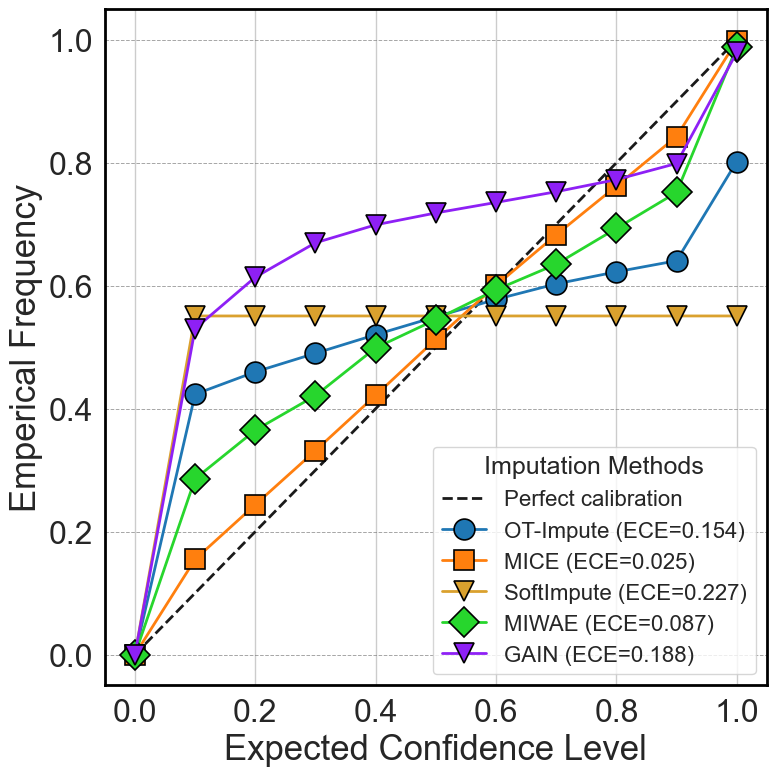

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Cancer_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Cancer_MCAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()
